In [1]:
!git clone https://github.com/facebookresearch/tribev2.git
%cd tribev2
!pip install -e ".[plotting]"   # includes brain visualization

fatal: destination path 'tribev2' already exists and is not an empty directory.
/content/tribev2
Obtaining file:///content/tribev2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tribev2 (pyproject.toml) ... done
  Created wheel for tribev2: filename=tribev2-0.1.0-0.editable-py3-none-any.whl size=17802 sha256=d6c1ecac4ba6098e4c988a6e42de7b14e6d5947f99932eda7c58010a37de3cf3
  Stored in directory: /tmp/pip-ephem-wheel-cache-1mmqsq4q/wheels/9c/c2/75/fe8948b6f8f93ed7c0092fe5ad0ff602b1bc6afaef5b2937d5
Successfully built tribev2
  Attempting uninstall: tribev2
    Found existing installation: tribev2 0.1.0
    Uninstalling tribev2-0.1.0:
      Successfully uninstalled tribev2-0.1.0


In [2]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from tribev2 import TribeModel

model = TribeModel.from_pretrained("facebook/tribev2", cache_folder = "./chace")

config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-03-28 19:43:09 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

In [6]:
df = model.get_events_dataframe(video_path="../randomedit.mp4")
preds, segments = model.predict(events=df)
print(preds.shape)  # should print (n_timesteps, 20484)

Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in ../randomedit.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)


MoviePy - Done.


/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [02:54<00:00, 174.27s/it]
2026-03-28 19:51:13 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-28 19:51:13 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[19:51:13 WARNING] Removing extractor text as there are no corresponding events
[19:51:13 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-03-28 19:54:44 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 15.56s at 30.0fps, shape (720, 1280)):
../randomedit.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 15.56s at 30.0fps, shape (720, 1280)):
../randomedit.mp4
Encoding video:   0%|          | 0/31 [00:00<?, ?it/s]2026-03-28 19:55:01 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (31, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (31, 20, 1408)
Encoding video: 100%|██████████| 31/31 [09:18<00:00, 18.03s/it]
[20:04:04 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-28 20:04:04 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[20:04:04 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoad

(16, 20484)


In [7]:
# this is to check if your output is working

print("Output shape:", preds.shape)
# e.g. (12, 20484) → 12 time steps, ~20k brain points

print("Segments:", segments)
# shows time windows your video was split into

print("Min / Max activation:", preds.min(), preds.max())

Output shape: (16, 20484)
Segments: [Segment(start=np.float64(0.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(1.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(2.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(3.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(4.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(5.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(6.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(7.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(8.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(9.0), duration=1.0, timeline='default', _trigger_idx=np.int64(2)), Segment(start=np.float64(10.0), duration=1.

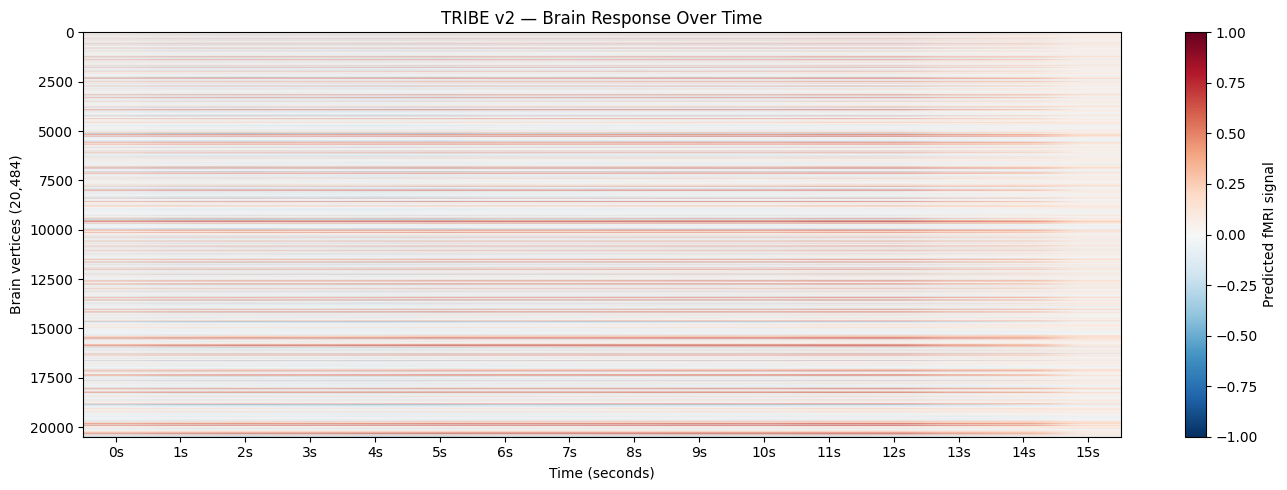

In [8]:
#this is for the heatmap
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 5))
plt.imshow(preds.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Predicted fMRI signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Brain vertices (20,484)')
plt.xticks(range(16), [f"{i}s" for i in range(16)])
plt.title('TRIBE v2 — Brain Response Over Time')
plt.tight_layout()
plt.show()


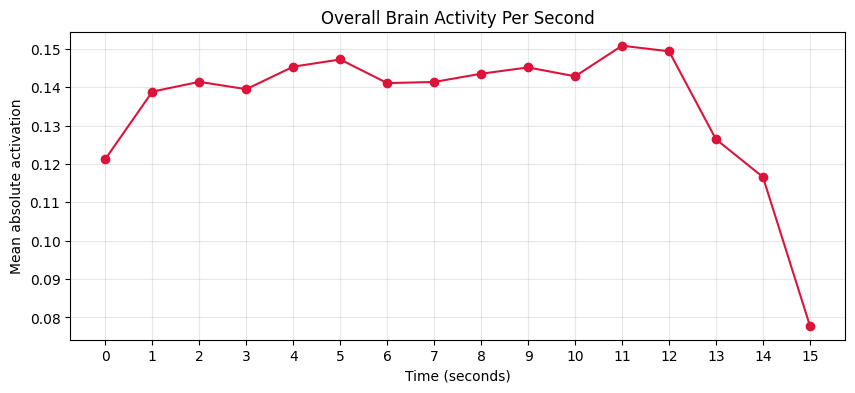

In [9]:
#  which second had the most brain activity
activation_per_second = np.abs(preds).mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(range(16), activation_per_second, marker='o', color='crimson')
plt.xlabel('Time (seconds)')
plt.ylabel('Mean absolute activation')
plt.title('Overall Brain Activity Per Second')
plt.xticks(range(16))
plt.grid(True, alpha=0.3)
plt.show()

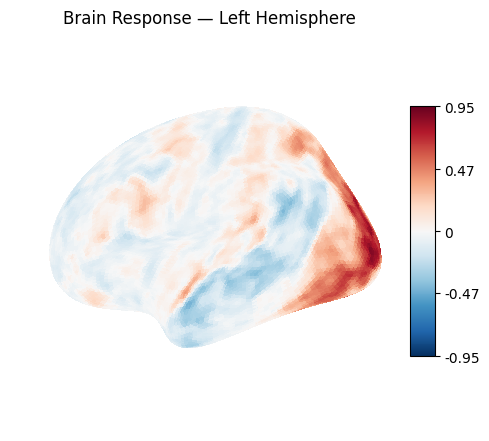

In [11]:
from nilearn import datasets, plotting
import numpy as np

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
mean_pred = preds.mean(axis=0)

plotting.plot_surf_stat_map(
    fsaverage.infl_left, mean_pred[:10242],
    hemi='left', view='lateral',
    bg_map=fsaverage.sulc_left,
    colorbar=True, cmap='RdBu_r',
    title='Brain Response — Left Hemisphere'
)
plotting.show()

In [12]:
!pip install nilearn matplotlib -q
from nilearn import datasets, plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

In [20]:
from nilearn import datasets, plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

frames = []

for t in range(16):
    fig_anim, ax = plt.subplots(figsize=(7, 5),
                                 subplot_kw={'projection': '3d'})  # ← fix

    plotting.plot_surf_stat_map(
        fsaverage.infl_left, preds[t, :10242],
        hemi='left', view='lateral',
        bg_map=fsaverage.sulc_left,
        colorbar=True, cmap='RdBu_r',
        vmax=1.0,
        title=f'Brain Response — Second {t}',
        axes=ax
    )

    fig_anim.canvas.draw()
    buf = fig_anim.canvas.buffer_rgba()
    image = np.asarray(buf)[..., :3]
    frames.append(image)
    plt.close(fig_anim)
    print(f"Frame {t+1}/16 done ✓")

print(f"\nTotal frames: {len(frames)}")

Frame 1/16 done ✓
Frame 2/16 done ✓
Frame 3/16 done ✓
Frame 4/16 done ✓
Frame 5/16 done ✓
Frame 6/16 done ✓
Frame 7/16 done ✓
Frame 8/16 done ✓
Frame 9/16 done ✓
Frame 10/16 done ✓
Frame 11/16 done ✓
Frame 12/16 done ✓
Frame 13/16 done ✓
Frame 14/16 done ✓
Frame 15/16 done ✓
Frame 16/16 done ✓

Total frames: 16


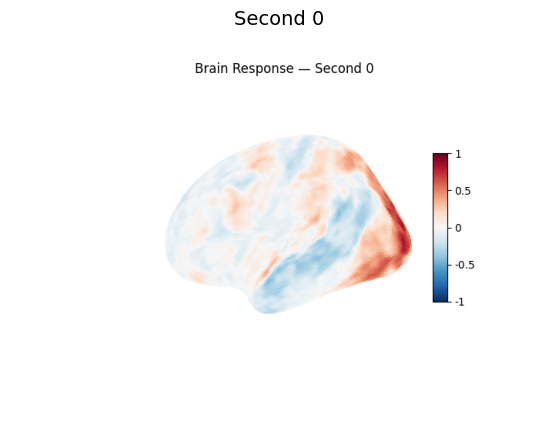

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')
im = ax.imshow(frames[0])

def update(i):
    im.set_data(frames[i])
    ax.set_title(f'Second {i}', fontsize=14)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=16, interval=600)
HTML(ani.to_jshtml())

In [22]:
ani.save('brain_response.gif', writer='pillow', fps=2)
print("Saved! ✓")

Saved! ✓


In [23]:
from google.colab import files
files.download('brain_response.gif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>